In [18]:
import os
import sys
import contextlib

from matplotlib import pyplot as plt
import numpy as np

import mne
import mne_icalabel
from asrpy import ASR

def load_subject_data(file_path):
    # Load the .set file using mne
    return mne.io.read_raw_eeglab(file_path, preload=True)

def notch_highpass_bads_rereference(data: mne.io.Raw, notch_freq=60, highpass_freq=1, bads=None):
    dataCopy = data.copy()
    dataCopy.notch_filter(freqs=notch_freq, verbose=False)
    dataCopy.filter(l_freq=highpass_freq, h_freq=None, verbose=False)
    if bads is not None:
        dataCopy.info['bads'].extend(bads)
    dataCopy.set_eeg_reference('average', verbose=False)
    return dataCopy

def run_ica(data: mne.io.Raw, n_components=None, exclude=None, plot_sources=False):
    dataCopy = data.copy()

    ica = mne.preprocessing.ICA(n_components=n_components, random_state=0, method='infomax', fit_params=dict(extended=True))
    ica.fit(dataCopy, verbose=False)
    ica.exclude = exclude
    if exclude is None:
        labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')
        ica.exclude = [idx for idx, label in enumerate(labels['labels']) if label != 'brain']
    else:
        ica.exclude = exclude
    if plot_sources:
        plot = ica.plot_sources(dataCopy)
    icaData = ica.apply(dataCopy, verbose=False)

    return icaData

def run_asr(data: mne.io.Raw, calibration_start=0, calibration_end=60, cutoff=10, win_overlap=0.9, max_bad_chans=0.1):
    dataCopy = data.copy()

    asr = ASR(dataCopy.info['sfreq'], cutoff=cutoff, win_overlap=win_overlap, max_bad_chans=max_bad_chans)
    asr.fit(dataCopy.copy().crop(calibration_start, calibration_end))
    asrData = asr.transform(dataCopy)
    asrData.set_eeg_reference('average', verbose=False)
    return asrData

def bandpass_filter(data: mne.io.Raw, l_freq, h_freq):
    return data.copy().filter(l_freq=l_freq, h_freq=h_freq, method="fir", verbose=False)

def epoch_data(data: mne.io.Raw, e_start, e_end):
    epochs = mne.Epochs(data, tmin=e_start, tmax=e_end, baseline=None, preload=True, verbose=False)
    epochs.crop(tmin=e_start, tmax=e_end)
    return epochs

def epoch_data_baseline(data: mne.io.Raw, b_start, b_end, e_start, e_end):
    epochs = mne.Epochs(data, tmin=b_start, tmax=e_end, baseline=(b_start,b_end), preload=True, verbose=False)
    epochs.crop(tmin=e_start, tmax=e_end)
    return epochs

def left_right_power(epochs: mne.Epochs, band, left_task, right_task, left_channels, right_channels):
    epochsCopy = epochs.copy()
    epochsCopy.drop_channels(epochsCopy.info['bads'])

    psd = epochsCopy.compute_psd(fmin=band[0], fmax=band[1])

    psd_left = psd[left_task]
    psd_right = psd[right_task]

    psd_left_data = psd_left.get_data() # Shape: (n_epochs, n_channels, n_freqs)
    psd_right_data = psd_right.get_data()

    left_mean_power = psd_left_data.mean(axis=-1) # Shape: (n_epochs, n_channels)
    right_mean_power = psd_right_data.mean(axis=-1)

    left_channel_indices = [epochsCopy.ch_names.index(ch) for ch in left_channels]
    right_channel_indices = [epochsCopy.ch_names.index(ch) for ch in right_channels]

    left_hand_left_brain = left_mean_power[:, left_channel_indices].mean(axis=-1)
    left_hand_right_brain = left_mean_power[:, right_channel_indices].mean(axis=-1)
    right_hand_left_brain = right_mean_power[:, left_channel_indices].mean(axis=-1)
    right_hand_right_brain = right_mean_power[:, right_channel_indices].mean(axis=-1)

    return (left_hand_left_brain, left_hand_right_brain, right_hand_left_brain, right_hand_right_brain)

In [19]:
%matplotlib ipympl

In [20]:
def calculate_subject_alpha_powers(subject, bads=None, show_plots=False, n_components=15, ica_exclude=None, use_asr=True, epoch_start=0, epoch_end=4):
    left_coi = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"]
    right_coi = ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"]

    file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-3_eeg.set"
    data = load_subject_data(file_path)
    # if subject == '002':
    #     data = data.crop(0, 113)
    data = notch_highpass_bads_rereference(data, notch_freq=60, highpass_freq=1, bads=bads)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    data = run_ica(data, n_components, ica_exclude, plot_sources=show_plots)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    if use_asr:
        data = run_asr(data, cutoff=20, calibration_end=30)
        if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    # data = bandpass_filter(data, 8, 30)
    # if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
    epochs = epoch_data(data, epoch_start, epoch_end)

    return left_right_power(epochs, (8, 13), 'TASK1T1', 'TASK1T2', left_coi, right_coi)

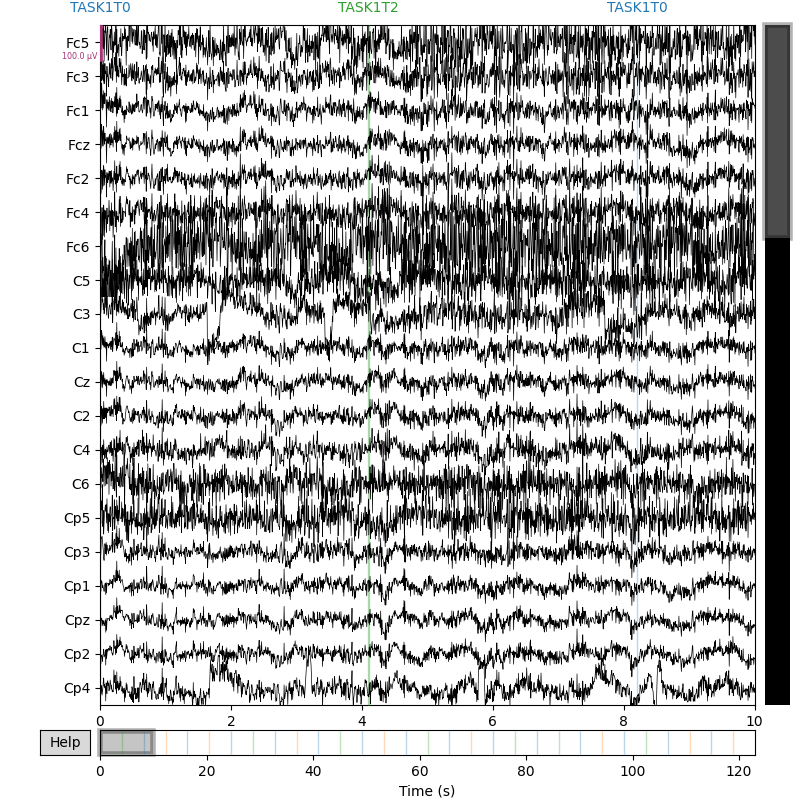

/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_46584/59796964.py:32: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


Creating RawArray with float64 data, n_channels=30, n_times=19680
    Range : 0 ... 19679 =      0.000 ...   122.994 secs
Ready.


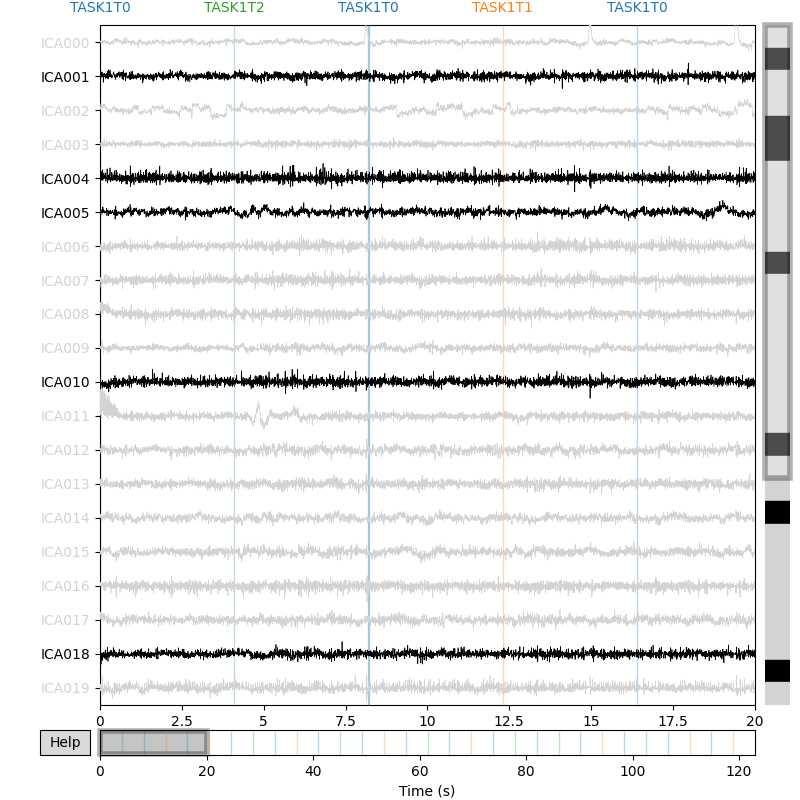

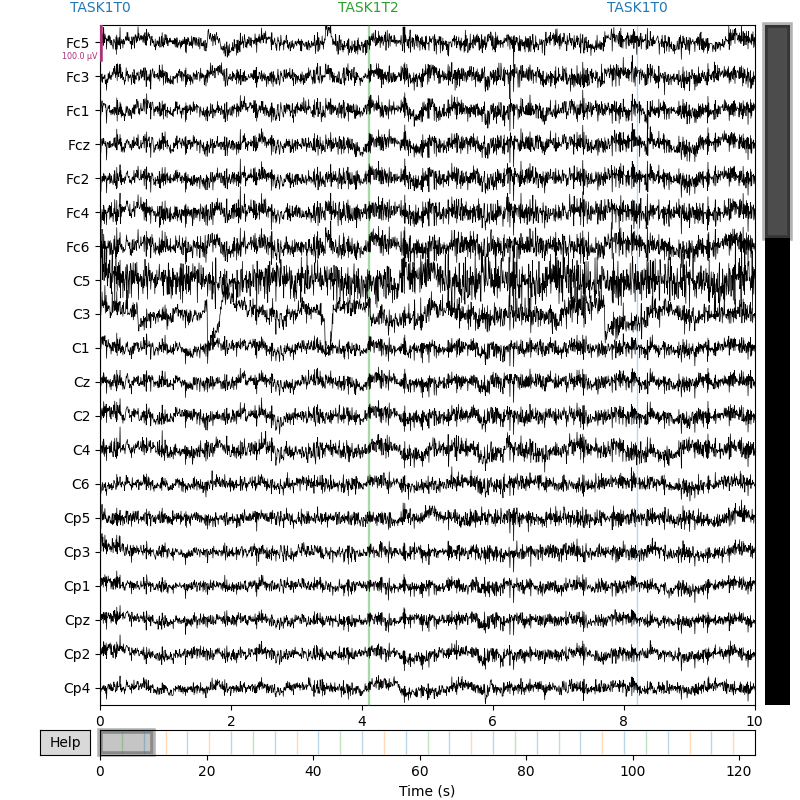

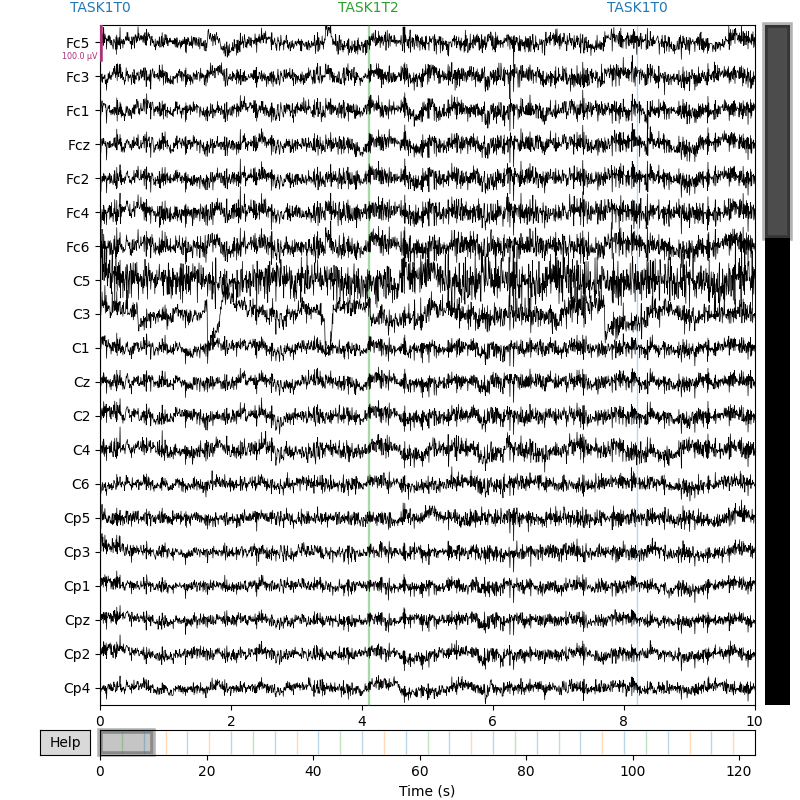

    Using multitaper spectrum estimation with 7 DPSS windows


In [36]:
left_hand_left_brain, left_hand_right_brain, right_hand_left_brain, right_hand_right_brain = calculate_subject_alpha_powers('017', n_components=30, show_plots=True)

In [38]:
subject = '017'
show_plots = False
n_components = 60
use_asr = True
ica_exclude = None
bads = None
baseline_epoch_start = 2
baseline_epoch_end = 4
data_epoch_start = 0
data_epoch_end = 2
left_coi = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"]
right_coi = ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"]

file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-3_eeg.set"
data = load_subject_data(file_path)
# if subject == '002':
#     data = data.crop(0, 113)
data = notch_highpass_bads_rereference(data, notch_freq=60, highpass_freq=1, bads=bads)
if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
data = run_ica(data, n_components, ica_exclude, plot_sources=show_plots)
if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
if use_asr:
    data = run_asr(data, cutoff=20, calibration_end=30)
    if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
# data = bandpass_filter(data, 8, 30)
if show_plots: data.plot(duration=10, scalings={'eeg': 50e-6})
data_epochs = epoch_data(data, data_epoch_start, data_epoch_end)
baseline_epochs = epoch_data_baseline(data, baseline_epoch_start, baseline_epoch_end)

/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_46584/59796964.py:32: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


KeyboardInterrupt: 

In [37]:
data_epochs.compute_psd().plot()

NameError: name 'data_epochs' is not defined

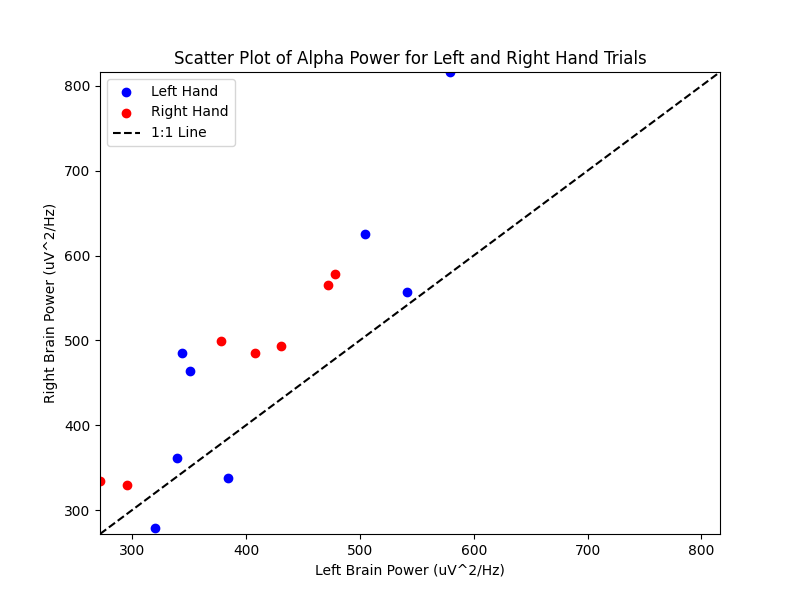

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(left_hand_left_brain*1e12, left_hand_right_brain*1e12, color='blue', label='Left Hand')
plt.scatter(right_hand_left_brain*1e12, right_hand_right_brain*1e12, color='red', label='Right Hand')
plt.xlabel('Left Brain Power (uV^2/Hz)')
plt.ylabel('Right Brain Power (uV^2/Hz)')
plt.title('Scatter Plot of Alpha Power for Left and Right Hand Trials')

# Determine limits from all data for same scaling
all_values = np.concatenate([left_hand_left_brain, left_hand_right_brain, right_hand_left_brain, right_hand_right_brain])
min_val = all_values.min()*1e12
max_val = all_values.max()*1e12
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Plot 1:1 line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

plt.legend()
plt.show()